# Risk Score Calculation for Chromosomes 13, 18, and 21 Using Logistic Approach

In [ ]:
# Read the new dataset
df_jk = pd.read_csv('/mnt/rdisk/duydao/khuongduying.github.io/statistics/JK_report.csv')

In [15]:
# Filter for high risk cases based on the existing risk columns
# Create boolean mask for high risk cases using the existing risk assessment columns
high_risk_mask = (
    (df_jk['T21 risk'].str.lower() == 'high') |
    (df_jk['T18 risk'].str.lower() == 'high') |
    (df_jk['T13 risk'].str.lower() == 'high')
)

# Filter the dataframe to keep only high risk cases
df_jk_high_risk = df_jk[high_risk_mask]

print(f"Original dataset: {len(df_jk)} rows")
print(f"High risk cases: {len(df_jk_high_risk)} rows")
print(f"Percentage of high risk cases: {len(df_jk_high_risk)/len(df_jk)*100:.1f}%")

# Show breakdown by risk type
print("\nRisk breakdown:")
print(f"T21 high risk: {(df_jk['T21 risk'].str.lower() == 'high').sum()} cases")
print(f"T18 high risk: {(df_jk['T18 risk'].str.lower() == 'high').sum()} cases") 
print(f"T13 high risk: {(df_jk['T13 risk'].str.lower() == 'high').sum()} cases")

# Display the filtered results
df_jk_high_risk.head()

Original dataset: 441 rows
High risk cases: 29 rows
Percentage of high risk cases: 6.6%

Risk breakdown:
T21 high risk: 17 cases
T18 high risk: 10 cases
T13 high risk: 2 cases


,tid,sampleID,ReportType,Datavolumn,note,T13 risk,T18 risk,T21 risk,risk score of T13,risk score of T18,...,Angelman syndrome,Prader–Willi syndrome,15q26 duplication syndrome,16p12.2 microdeletion syndrome,17p13.3 deletion syndrome,Smith-Magenis syndrome,Potocki-Lupski syndrome,22q11.2 deletion syndrome,10p14-p13 deletion syndrome\n(DiGeorge 2 syndrome),22q11.2 deletion syndrome\n(DiGeorge syndrome)
118,S250102680_L01_4,N134B-1,NIPT-BASE,15M,NaN,low,low,high,1/8030591900,1/5230881157,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,S250102680_L01_2,N133B-1,NIPT-BASE,15M,NaN,low,high,low,1/612553201,>1/20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,S250102680_L01_12,N134B-2,NIPT-BASE,15M,NaN,low,low,high,1/3441710328,1/3006116462,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121,S250102680_L01_5,N134C-1,NIPT-BASE,15M,NaN,low,low,high,1/4792571586,1/1290472369,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
126,S250102680_L01_10,N133B-2,NIPT-BASE,15M,NaN,low,high,low,1/598816024,>1/20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# Save the results dataframe to CSV
results_df.to_csv('/mnt/rdisk/duydao/khuongduying.github.io/statistics/trisomy_risk_results.csv', index=False)

print("Results saved to: /mnt/rdisk/duydao/khuongduying.github.io/statistics/trisomy_risk_results.csv")
print(f"Saved {len(results_df)} rows with {len(results_df.columns)} columns")

Results saved to: /mnt/rdisk/duydao/khuongduying.github.io/statistics/trisomy_risk_results.csv
Saved 34 rows with 144 columns


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_trisomy_risk_logistic(z_score, trisomy_type='T21', prior_risk=None):
    """
    Calculate trisomy risk using logistic approach for chromosomes 13, 18, and 21
    
    Parameters:
    - z_score: observed z-score
    - trisomy_type: 'T21', 'T18', or 'T13'
    - prior_risk: a priori risk (if None, uses default values)
    
    Returns:
    - probability (0-1)
    """
    
    # Default prior risks based on maternal age and clinical data
    if prior_risk is None:
        prior_risks = {
            'T21': 0.001,   # 1 in 1000 (0.1%)
            'T18': 0.0003,  # 1 in 3333 (0.03%)
            'T13': 0.0002   # 1 in 5000 (0.02%)
        }
        prior_risk = prior_risks.get(trisomy_type, 0.001)
    
    # Convert prior risk to log odds
    prior_log_odds = np.log(prior_risk / (1 - prior_risk))
    
    # Trisomy-specific parameters for logistic function
    # These are tuned based on clinical performance expectations
    logistic_params = {
        'T21': {'coefficient': 2.0, 'intercept': -6.0},   # Most sensitive
        'T18': {'coefficient': 1.8, 'intercept': -5.5},   # Moderate sensitivity  
        'T13': {'coefficient': 1.6, 'intercept': -5.0}    # Lower sensitivity
    }
    
    params = logistic_params.get(trisomy_type, logistic_params['T21'])
    
    # Z-score contribution to log odds
    z_contribution = params['coefficient'] * z_score + params['intercept']
    
    # Combined log odds
    combined_log_odds = prior_log_odds + z_contribution
    
    # Convert back to probability using logistic function
    probability = 1 / (1 + np.exp(-combined_log_odds))
    
    return probability

def classify_risk_level(probability_pct):
    """Classify risk level based on probability percentage"""
    if probability_pct >= 99:
        return "Very High Risk"
    elif probability_pct >= 90:
        return "High Risk"
    elif probability_pct >= 50:
        return "Moderate Risk"
    elif probability_pct >= 10:
        return "Low-Moderate Risk"
    elif probability_pct >= 1:
        return "Low Risk"
    else:
        return "Very Low Risk"

def calculate_all_trisomy_risks(df):
    """
    Calculate risk scores for all three trisomies
    Assumes columns: score21, score18, score13
    """
    results_df = df.copy()
    
    # Calculate risks for each trisomy
    trisomies = {
        'T21': 'score21',
        'T18': 'score18', 
        'T13': 'score13'
    }
    
    for trisomy, z_score_col in trisomies.items():
        if z_score_col in df.columns:
            # Calculate probabilities
            prob_col = f'{trisomy.lower()}_probability'
            prob_pct_col = f'{trisomy.lower()}_probability_pct'
            risk_level_col = f'{trisomy.lower()}_risk_level'
            
            results_df[prob_col] = df[z_score_col].apply(
                lambda x: calculate_trisomy_risk_logistic(x, trisomy) if pd.notna(x) else np.nan
            )
            
            results_df[prob_pct_col] = results_df[prob_col] * 100
            
            results_df[risk_level_col] = results_df[prob_pct_col].apply(
                lambda x: classify_risk_level(x) if pd.notna(x) else "Unknown"
            )
        else:
            print(f"Warning: Column {z_score_col} not found in dataframe")
    
    return results_df

In [ ]:
# # Read your data
# df = pd.read_csv('/mnt/rdisk/duydao/khuongduying.github.io/statistics/T21_high.csv')

### Add 5 random samples with T21 z-scores between 3 and 5

In [17]:
# Create DataFrame from the high risk dataset
df = df_jk_high_risk.copy()

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Create 5 new samples
new_samples = []
for i in range(5):
    # Generate random T21 z-score between 3 and 5
    random_z21 = np.random.uniform(3.0, 5.0)
    
    # Create a new sample row
    new_sample = {
        'tid': f'RANDOM_SAMPLE_{i+1}',
        'sampleID': f'TEST_{i+1}',
        'ReportType': 'NIPT-TEST',
        'Datavolumn': '10M',
        'note': np.nan,
        'T13 risk': 'low',
        'T18 risk': 'low', 
        'T21 risk': 'moderate',
        'risk score of T13': '1/10000000',
        'risk score of T18': '1/10000000',
        'risk score of T21': '1/100',
        'rawdata': np.random.uniform(20, 60),
        'uniqueread': np.random.uniform(15, 40),
        'uniqueGC': np.random.uniform(35, 45),
        'readQC': 'Passed',
        'GCQC': 'Passed',
        'fetalfraction': np.random.uniform(8, 20),
        'fetalgender': np.random.choice(['M', 'F']),
        'score21': random_z21,  # Our target z-score
        'score18': np.random.uniform(-2, 0),  # Random T18 z-score (normal range)
        'score13': np.random.uniform(-1, 1),  # Random T13 z-score (normal range)
        'score22': np.random.uniform(-2, 2),  # Random other chromosome scores
        'scoreXO': np.random.uniform(-3, 3),
        'scoreXXX': np.random.uniform(-3, 3),
        'scoreXXY': np.random.uniform(-3, 3),
        'scoreXYY': np.random.uniform(-3, 3)
    }
    
    # Fill in all other columns with NaN to match the original dataframe structure
    for col in df_jk_high_risk.columns:
        if col not in new_sample:
            new_sample[col] = np.nan
    
    new_samples.append(new_sample)

# Create DataFrame from new samples
new_df = pd.DataFrame(new_samples)

# Ensure column order matches original dataframe
new_df = new_df.reindex(columns=df_jk_high_risk.columns)

# Append to original dataframe
df = pd.concat([df_jk_high_risk, new_df], ignore_index=True)

print(f"Added 5 random samples. DataFrame now has {len(df)} rows.")
print("\nNew samples added:")
print(df[['tid', 'score21', 'score18', 'score13']].tail())


Added 5 random samples. DataFrame now has 34 rows.

New samples added:
                tid   score21   score18   score13
29  RANDOM_SAMPLE_1  3.749080 -1.800050 -0.081502
30  RANDOM_SAMPLE_2  4.877105 -1.136110 -0.417542
31  RANDOM_SAMPLE_3  4.570352 -0.639385 -0.099001
32  RANDOM_SAMPLE_4  3.461788 -0.181359 -0.482440
33  RANDOM_SAMPLE_5  4.939169 -1.346918  0.140888


In [18]:
# Calculate risks for all trisomies
results_df = calculate_all_trisomy_risks(df)

# Display results
print("Trisomy Risk Calculation Results:")
print("=" * 80)

# Show available columns first
print("Available columns:", results_df.columns.tolist())
print()

# Display T21 results (since we know this column exists)
if 'score21' in results_df.columns:
    print("Chromosome 21 (T21) Results:")
    display_cols = ['tid', 'score21', 't21_probability_pct', 't21_risk_level']
    available_cols = [col for col in display_cols if col in results_df.columns]
    print(results_df[available_cols].head(20))
    print()

# Display T18 results if available
if 'score18' in results_df.columns:
    print("Chromosome 18 (T18) Results:")
    display_cols = ['tid', 'score18', 't18_probability_pct', 't18_risk_level']
    available_cols = [col for col in display_cols if col in results_df.columns]
    print(results_df[available_cols].head(20))
    print()

# Display T13 results if available  
if 'score13' in results_df.columns:
    print("Chromosome 13 (T13) Results:")
    display_cols = ['tid', 'score13', 't13_probability_pct', 't13_risk_level']
    available_cols = [col for col in display_cols if col in results_df.columns]
    print(results_df[available_cols].head(20))
    print()

# Summary statistics
print("Summary Statistics:")
print("=" * 50)

for trisomy in ['T21', 'T18', 'T13']:
    z_col = f'score{trisomy[-2:]}'
    prob_col = f'{trisomy.lower()}_probability_pct'
    
    if z_col in results_df.columns and prob_col in results_df.columns:
        print(f"\n{trisomy} Statistics:")
        print(f"  Z-scores - Mean: {results_df[z_col].mean():.2f}, "
              f"Std: {results_df[z_col].std():.2f}, "
              f"Range: {results_df[z_col].min():.1f} to {results_df[z_col].max():.1f}")
        print(f"  Risk % - Mean: {results_df[prob_col].mean():.1f}%, "
              f"Median: {results_df[prob_col].median():.1f}%, "
              f"Max: {results_df[prob_col].max():.1f}%")
        
        # Risk level distribution
        if f'{trisomy.lower()}_risk_level' in results_df.columns:
            risk_dist = results_df[f'{trisomy.lower()}_risk_level'].value_counts()
            print(f"  Risk Distribution:")
            for level, count in risk_dist.items():
                pct = (count / len(results_df)) * 100
                print(f"    {level}: {count} ({pct:.1f}%)")

Trisomy Risk Calculation Results:
Available columns: ['tid', 'sampleID', 'ReportType', 'Datavolumn', 'note', 'T13 risk', 'T18 risk', 'T21 risk', 'risk score of T13', 'risk score of T18', 'risk score of T21', 'rawdata', 'uniqueread', 'uniqueGC', 'readQC', 'GCQC', 'fetalfraction', 'fetalgender', 'score1', 'score2', 'score3', 'score4', 'score5', 'score6', 'score7', 'score8', 'score9', 'score10', 'score11', 'score12', 'score13', 'score14', 'score15', 'score16', 'score17', 'score18', 'score19', 'score20', 'score21', 'score22', 'scoreXO', 'scoreXXX', 'scoreXXY', 'scoreXYY', 'Partial monosomy 1p', 'Monosomy 1q21→q32', 'Monosomy 1q42→qter', 'Trisomy 1q23→qter', 'Partial monosomy 2p', 'Partial trisomy 2p', 'Partial monosomy 2q', 'Partial trisomy 2q', 'Monosomy 3p11→p21', 'Monosomy 3p25→pter', 'Partial trisomy 3p', 'Partial monosomy 3q', 'Partial trisomy 3q', 'Partial monosomy3p and partial trisomy 3q', 'Partial monosomy 4p', 'Partial trisomy 4p', 'Monosomy 4q21→q31', 'Monosomy 4q31→qter', 'Part

In [19]:
def probability_to_ratio(probability):
    """
    Convert probability to "1 in X" format
    
    Parameters:
    - probability: float between 0 and 1
    
    Returns:
    - string in format "1 in X" or ">99%" for very high probabilities
    """
    if pd.isna(probability) or probability <= 0:
        return "Invalid"
    elif probability >= 0.99:
        return f">99% ({probability*100:.1f}%)"
    elif probability >= 0.01:  # 1% or higher, show as percentage
        return f"{probability*100:.1f}%"
    else:
        # Convert to "1 in X" format
        ratio = int(round(1 / probability))
        return f"1 in {ratio:,}"

def format_probability_comprehensive(probability):
    """
    Show both percentage and ratio format for comprehensive view
    """
    if pd.isna(probability) or probability <= 0:
        return "Invalid", "Invalid"
    
    # Percentage format
    pct_format = f"{probability*100:.3f}%" if probability < 0.01 else f"{probability*100:.1f}%"
    
    # Ratio format  
    if probability >= 0.99:
        ratio_format = ">99%"
    elif probability >= 0.01:
        ratio_format = f"{probability*100:.1f}%"
    else:
        ratio = int(round(1 / probability))
        ratio_format = f"1 in {ratio:,}"
    
    return pct_format, ratio_format

# Add ratio columns to results
def add_ratio_columns(results_df):
    """Add ratio format columns for all trisomies"""
    
    for trisomy in ['T21', 'T18', 'T13']:
        prob_col = f'{trisomy.lower()}_probability'
        ratio_col = f'{trisomy.lower()}_ratio'
        comprehensive_col = f'{trisomy.lower()}_risk_summary'
        
        if prob_col in results_df.columns:
            # Add simple ratio column
            results_df[ratio_col] = results_df[prob_col].apply(probability_to_ratio)
            
            # Add comprehensive format (percentage + ratio)
            results_df[comprehensive_col] = results_df[prob_col].apply(
                lambda x: f"{format_probability_comprehensive(x)[0]} ({format_probability_comprehensive(x)[1]})" 
                if pd.notna(x) else "Unknown"
            )
    
    return results_df

# Apply the ratio formatting
results_df = add_ratio_columns(results_df)

print("Trisomy Risk Results with Ratio Format:")
print("=" * 100)

# Display T21 results with ratio format
if 'score21' in results_df.columns:
    print("Chromosome 21 (T21) Results:")
    display_cols = ['tid', 'score21', 't21_probability_pct', 't21_ratio', 't21_risk_level']
    available_cols = [col for col in display_cols if col in results_df.columns]
    print(results_df[available_cols].head(10))
    print()

# Display T18 results if available
if 'score18' in results_df.columns:
    print("Chromosome 18 (T18) Results:")
    display_cols = ['tid', 'score18', 't18_probability_pct', 't18_ratio', 't18_risk_level']
    available_cols = [col for col in display_cols if col in results_df.columns]
    print(results_df[available_cols].head(10))
    print()

# Display T13 results if available  
if 'score13' in results_df.columns:
    print("Chromosome 13 (T13) Results:")
    display_cols = ['tid', 'score13', 't13_probability_pct', 't13_ratio', 't13_risk_level']
    available_cols = [col for col in display_cols if col in results_df.columns]
    print(results_df[available_cols].head(10))
    print()

Trisomy Risk Results with Ratio Format:
Chromosome 21 (T21) Results:
                 tid  score21  t21_probability_pct      t21_ratio  \
0   S250102680_L01_4   12.306            99.999175  >99% (100.0%)   
1   S250102680_L01_2    0.257             0.000415   1 in 241,050   
2  S250102680_L01_12   10.745            99.981282  >99% (100.0%)   
3   S250102680_L01_5   12.573            99.999516  >99% (100.0%)   
4  S250102680_L01_10    0.496             0.000669   1 in 149,457   
5  S250102680_L01_13   11.793            99.997698  >99% (100.0%)   
6  S250127334_L01_18    0.743             0.001097    1 in 91,196   
7  S250127345_L01_13    0.441             0.000599   1 in 166,835   
8  S250127408_L01_13    1.314             0.003435    1 in 29,109   
9  S250127493_L01_17   10.215            99.945992   >99% (99.9%)   

   t21_risk_level  
0  Very High Risk  
1   Very Low Risk  
2  Very High Risk  
3  Very High Risk  
4   Very Low Risk  
5  Very High Risk  
6   Very Low Risk  
7   Very Lo

In [20]:
def probability_to_ratio_custom(probability):
    """
    Convert probability to "1 in X" format with custom logic
    - Use ">1/20" if probability > 5%
    - Otherwise use "1 in X" format
    """
    if pd.isna(probability) or probability <= 0:
        return "Invalid"
    elif probability > 0.05:  # More than 5%
        return ">1/20"
    else:
        # Convert to "1 in X" format
        ratio = int(round(1 / probability))
        return f"1/{ratio:,}"

def classify_risk_level_custom(probability_pct):
    """
    Classify risk level with custom logic:
    - High Risk if >5% probability
    - Low Risk otherwise
    """
    if pd.isna(probability_pct):
        return "Unknown"
    elif probability_pct > 5.0:  # More than 5%
        return "High Risk"
    else:
        return "Low Risk"

def calculate_all_trisomy_risks_custom(df):
    """
    Calculate risk scores for all three trisomies with custom formatting
    """
    results_df = df.copy()
    
    # Calculate risks for each trisomy
    trisomies = {
        'T21': 'score21',
        'T18': 'score18', 
        'T13': 'score13'
    }
    
    for trisomy, z_score_col in trisomies.items():
        if z_score_col in df.columns:
            # Calculate probabilities
            prob_col = f'{trisomy.lower()}_probability'
            prob_pct_col = f'{trisomy.lower()}_probability_pct'
            ratio_col = f'{trisomy.lower()}_ratio'
            risk_level_col = f'{trisomy.lower()}_risk_level'
            
            # Calculate base probability
            results_df[prob_col] = df[z_score_col].apply(
                lambda x: calculate_trisomy_risk_logistic(x, trisomy) if pd.notna(x) else np.nan
            )
            
            # Convert to percentage
            results_df[prob_pct_col] = results_df[prob_col] * 100
            
            # Apply custom ratio formatting
            results_df[ratio_col] = results_df[prob_col].apply(probability_to_ratio_custom)
            
            # Apply custom risk level classification
            results_df[risk_level_col] = results_df[prob_pct_col].apply(classify_risk_level_custom)
            
        else:
            print(f"Warning: Column {z_score_col} not found in dataframe")
    
    return results_df

# Recalculate with custom logic
results_df = calculate_all_trisomy_risks_custom(df)

print("Trisomy Risk Results with Custom Logic:")
print("=" * 100)
print("Custom Rules:")
print("- Probability ratio: '>1/20' if >5%, otherwise '1/X'")
print("- Risk level: 'High Risk' if >5%, otherwise 'Low Risk'")
print("=" * 100)

# Display T21 results with custom format
if 'score21' in results_df.columns:
    print("\nChromosome 21 (T21) Results:")
    display_cols = ['tid', 'score21', 't21_probability_pct', 't21_ratio', 't21_risk_level']
    available_cols = [col for col in display_cols if col in results_df.columns]
    print(results_df[available_cols].head(15))

# Display T18 results if available
if 'score18' in results_df.columns:
    print("\nChromosome 18 (T18) Results:")
    display_cols = ['tid', 'score18', 't18_probability_pct', 't18_ratio', 't18_risk_level']
    available_cols = [col for col in display_cols if col in results_df.columns]
    print(results_df[available_cols].head(15))

# Display T13 results if available  
if 'score13' in results_df.columns:
    print("\nChromosome 13 (T13) Results:")
    display_cols = ['tid', 'score13', 't13_probability_pct', 't13_ratio', 't13_risk_level']
    available_cols = [col for col in display_cols if col in results_df.columns]
    print(results_df[available_cols].head(15))

Trisomy Risk Results with Custom Logic:
Custom Rules:
- Probability ratio: '>1/20' if >5%, otherwise '1/X'
- Risk level: 'High Risk' if >5%, otherwise 'Low Risk'

Chromosome 21 (T21) Results:
                  tid  score21  t21_probability_pct  t21_ratio t21_risk_level
0    S250102680_L01_4   12.306            99.999175      >1/20      High Risk
1    S250102680_L01_2    0.257             0.000415  1/241,050       Low Risk
2   S250102680_L01_12   10.745            99.981282      >1/20      High Risk
3    S250102680_L01_5   12.573            99.999516      >1/20      High Risk
4   S250102680_L01_10    0.496             0.000669  1/149,457       Low Risk
5   S250102680_L01_13   11.793            99.997698      >1/20      High Risk
6   S250127334_L01_18    0.743             0.001097   1/91,196       Low Risk
7   S250127345_L01_13    0.441             0.000599  1/166,835       Low Risk
8   S250127408_L01_13    1.314             0.003435   1/29,109       Low Risk
9   S250127493_L01_17   10.2

## Visualization of Results

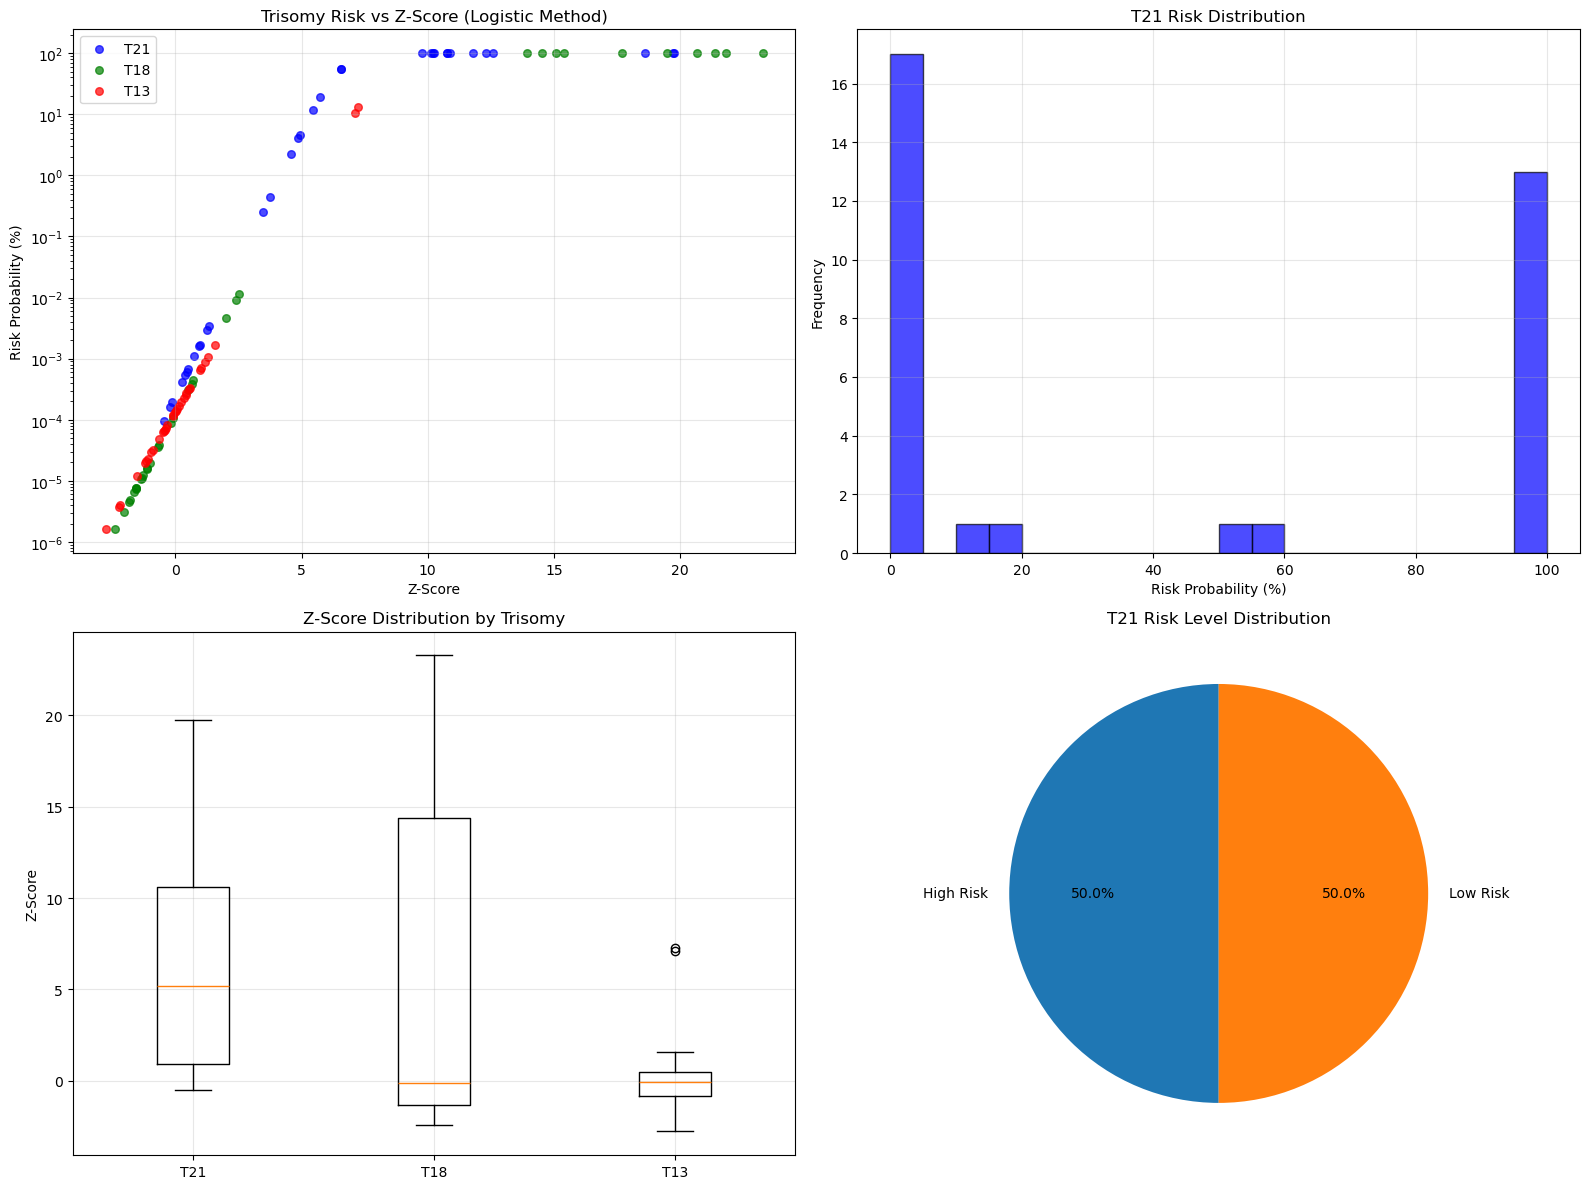

In [21]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Available trisomies for plotting
available_trisomies = []
for trisomy in ['T21', 'T18', 'T13']:
    z_col = f'score{trisomy[-2:]}'
    prob_col = f'{trisomy.lower()}_probability_pct'
    if z_col in results_df.columns and prob_col in results_df.columns:
        available_trisomies.append((trisomy, z_col, prob_col))

# Plot 1: Z-score vs Risk Probability for all available trisomies
colors = ['blue', 'green', 'red']
for i, (trisomy, z_col, prob_col) in enumerate(available_trisomies):
    axes[0,0].scatter(results_df[z_col], results_df[prob_col], 
                     alpha=0.7, label=trisomy, color=colors[i % len(colors)], s=30)

axes[0,0].set_xlabel('Z-Score')
axes[0,0].set_ylabel('Risk Probability (%)')
axes[0,0].set_title('Trisomy Risk vs Z-Score (Logistic Method)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_yscale('log')  # Log scale to better see low probabilities

# Plot 2: Risk distribution histogram for T21 (if available)
if len(available_trisomies) > 0:
    trisomy, z_col, prob_col = available_trisomies[0]  # Use first available
    axes[0,1].hist(results_df[prob_col].dropna(), bins=20, alpha=0.7, color='blue', edgecolor='black')
    axes[0,1].set_xlabel('Risk Probability (%)')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].set_title(f'{trisomy} Risk Distribution')
    axes[0,1].grid(True, alpha=0.3)

# Plot 3: Comparison of z-scores across trisomies (if multiple available)
if len(available_trisomies) > 1:
    z_data = []
    labels = []
    for trisomy, z_col, prob_col in available_trisomies:
        z_data.append(results_df[z_col].dropna())
        labels.append(trisomy)
    
    axes[1,0].boxplot(z_data, labels=labels)
    axes[1,0].set_ylabel('Z-Score')
    axes[1,0].set_title('Z-Score Distribution by Trisomy')
    axes[1,0].grid(True, alpha=0.3)
else:
    axes[1,0].text(0.5, 0.5, 'Multiple trisomies\nnot available', 
                   ha='center', va='center', transform=axes[1,0].transAxes)
    axes[1,0].set_title('Z-Score Comparison (Not Available)')

# Plot 4: Risk level pie chart for T21 (if available)
if len(available_trisomies) > 0:
    trisomy, z_col, prob_col = available_trisomies[0]
    risk_col = f'{trisomy.lower()}_risk_level'
    if risk_col in results_df.columns:
        risk_counts = results_df[risk_col].value_counts()
        axes[1,1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', startangle=90)
        axes[1,1].set_title(f'{trisomy} Risk Level Distribution')
    else:
        axes[1,1].text(0.5, 0.5, 'Risk levels\nnot calculated', 
                       ha='center', va='center', transform=axes[1,1].transAxes)

plt.tight_layout()
plt.show()